
# Bank Marketing Project

**Course:** BIA-5302  
**Topic:** Predicting whether a client subscribes to a term deposit  

This notebook follows the project guideline: data exploration, preprocessing, training at least two Python models, evaluation using accuracy/precision/recall/F1, confusion matrices, and final conclusions.


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 1. Load the datasets

In [4]:

# Use the exact uploaded filenames
train = pd.read_csv(r"C:\Users\smitn\OneDrive\Desktop\Sem 3\Machine Learning\Project\trainset.csv")
test = pd.read_csv(r"C:\Users\smitn\OneDrive\Desktop\Sem 3\Machine Learning\Project\testset.csv")

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Columns:')
print(train.columns.tolist())

train.head()


Train shape: (29271, 15)
Test shape : (11917, 15)
Columns:
['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'poutcome', 'nr.employed', 'Subscribed']


,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,campaign,pdays,poutcome,nr.employed,Subscribed
0,41,blue-collar,divorced,basic.4y,yes,no,telephone,may,mon,1575,1,999,nonexistent,5191.0,yes
1,49,entrepreneur,married,university.degree,yes,no,telephone,may,mon,1042,1,999,nonexistent,5191.0,yes
2,49,technician,married,basic.9y,no,no,telephone,may,mon,1467,1,999,nonexistent,5191.0,yes
3,41,technician,married,professional.course,yes,no,telephone,may,mon,579,1,999,nonexistent,5191.0,yes
4,45,blue-collar,married,basic.9y,yes,no,telephone,may,mon,461,1,999,nonexistent,5191.0,yes


## 2. Basic exploration

In [7]:

print('Training data types:')
display(train.dtypes)

print("Missing values before replacing 'unknown':")
display(train.isna().sum())

unknown_counts = (train == 'unknown').sum().sort_values(ascending=False)
print("Count of 'unknown' values:")
display(unknown_counts[unknown_counts > 0])

print('Numeric summary:')
display(train.describe())


Training data types:


age              int64
job             object
marital         object
education       object
housing         object
loan            object
contact         object
month           object
day_of_week     object
duration         int64
campaign         int64
pdays            int64
poutcome        object
nr.employed    float64
Subscribed      object
dtype: object

Missing values before replacing 'unknown':


age            0
job            0
marital        0
education      0
housing        0
loan           0
contact        0
month          0
day_of_week    0
duration       0
campaign       0
pdays          0
poutcome       0
nr.employed    0
Subscribed     0
dtype: int64

Count of 'unknown' values:


education    1227
housing       713
loan          713
job           260
marital        51
dtype: int64

Numeric summary:


,age,duration,campaign,pdays,nr.employed
count,29271.000000,29271.000000,29271.000000,29271.000000,29271.000000
mean,40.126132,266.334973,2.737556,988.235455,5205.364012
std,9.522742,272.826726,3.085469,102.879851,36.306531
min,17.000000,0.000000,1.000000,0.000000,5017.500000
25%,32.000000,103.000000,1.000000,999.000000,5191.000000
50%,39.000000,179.000000,2.000000,999.000000,5228.100000
75%,47.000000,327.000000,3.000000,999.000000,5228.100000
max,88.000000,4918.000000,56.000000,999.000000,5228.100000


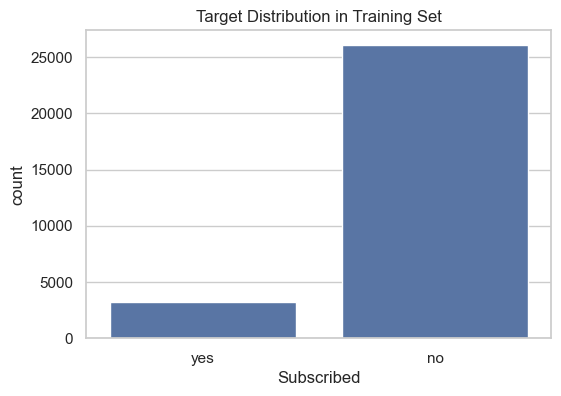

Subscription rate (%):


Subscribed
no     89.08
yes    10.92
Name: proportion, dtype: float64

In [8]:

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Subscribed')
plt.title('Target Distribution in Training Set')
plt.show()

subscription_rate = train['Subscribed'].value_counts(normalize=True).mul(100).round(2)
print('Subscription rate (%):')
display(subscription_rate)


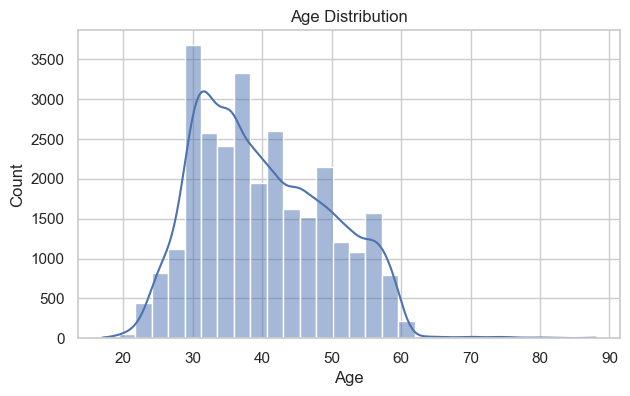

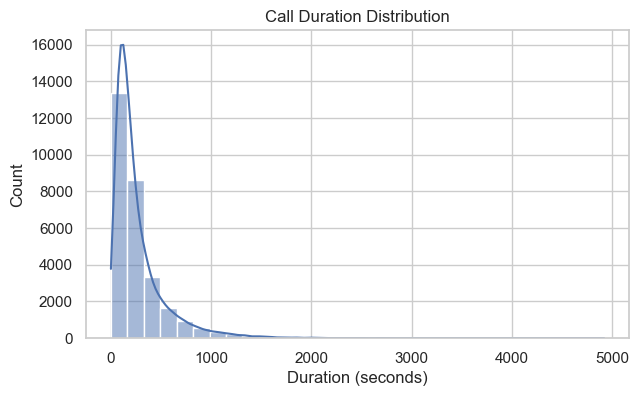

In [9]:

fig = plt.figure(figsize=(7,4))
sns.histplot(train['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

fig = plt.figure(figsize=(7,4))
sns.histplot(train['duration'], bins=30, kde=True)
plt.title('Call Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.show()


,job,subscription_rate
0,student,43.77
1,retired,21.78
2,admin.,12.38
3,unemployed,11.49
4,management,11.17
5,self-employed,11.00
6,entrepreneur,10.01
7,technician,9.95
8,unknown,9.62
9,services,9.11


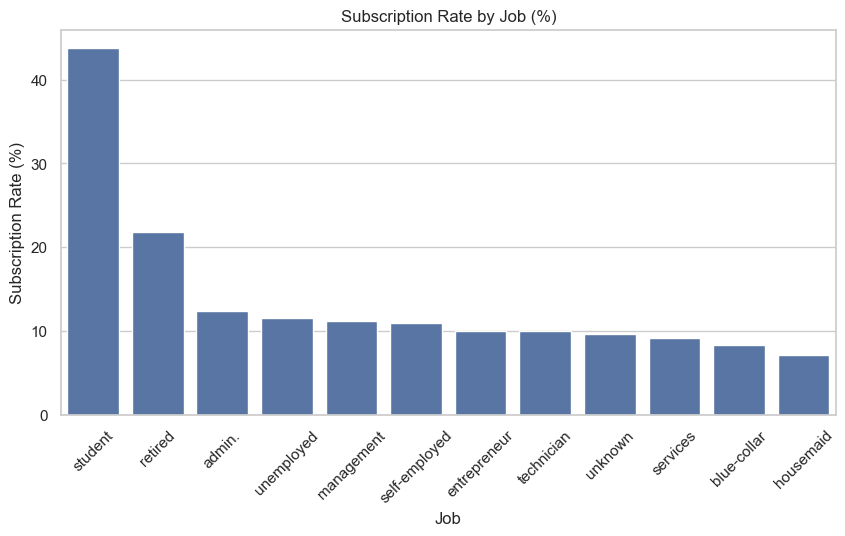

In [10]:

job_rate = (train.groupby('job')['Subscribed']
              .apply(lambda s: (s == 'yes').mean())
              .sort_values(ascending=False)
              .reset_index(name='subscription_rate'))
job_rate['subscription_rate'] = (job_rate['subscription_rate'] * 100).round(2)
display(job_rate)

plt.figure(figsize=(10,5))
sns.barplot(data=job_rate, x='job', y='subscription_rate')
plt.xticks(rotation=45)
plt.title('Subscription Rate by Job (%)')
plt.ylabel('Subscription Rate (%)')
plt.xlabel('Job')
plt.show()


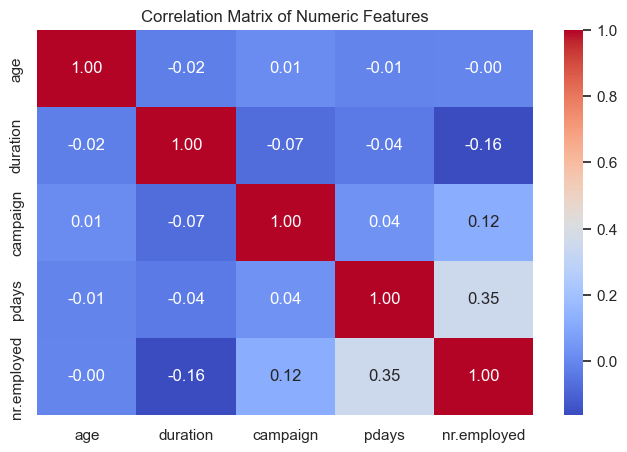

In [11]:

num_cols_for_corr = ['age', 'duration', 'campaign', 'pdays', 'nr.employed']
plt.figure(figsize=(8,5))
sns.heatmap(train[num_cols_for_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()



## 3. Preprocessing

Preprocessing steps used here:

- Replace the text value **`unknown`** with missing values (`NaN`)
- Use **median imputation** for numeric columns
- Use **most frequent imputation** for categorical columns
- One-hot encode categorical variables
- Standardize numeric columns for Logistic Regression

This is better than label-encoding all text fields because label encoding can incorrectly create fake numeric order among categories.


In [12]:

train = train.replace('unknown', np.nan)
test = test.replace('unknown', np.nan)

target = 'Subscribed'
X_train = train.drop(columns=[target])
y_train = train[target]
X_test = test.drop(columns=[target])
y_test = test[target]

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = X_train.select_dtypes(exclude='object').columns.tolist()

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)


Categorical columns: ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'nr.employed']


## 4. Build two models

In [13]:

# Preprocessor for Logistic Regression
numeric_transformer_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_lr = ColumnTransformer([
    ('num', numeric_transformer_lr, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

log_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(max_iter=5000, solver='liblinear', random_state=42))
])

# Preprocessor for Random Forest
numeric_transformer_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_rf = ColumnTransformer([
    ('num', numeric_transformer_rf, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

rf_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        min_samples_leaf=2,
        n_jobs=-1
    ))
])


## 5. Train the models and evaluate them on the test set


Logistic Regression
-------------------
              precision    recall  f1-score   support

          no       1.00      0.03      0.05     10473
         yes       0.12      1.00      0.22      1444

    accuracy                           0.14     11917
   macro avg       0.56      0.51      0.14     11917
weighted avg       0.89      0.14      0.07     11917



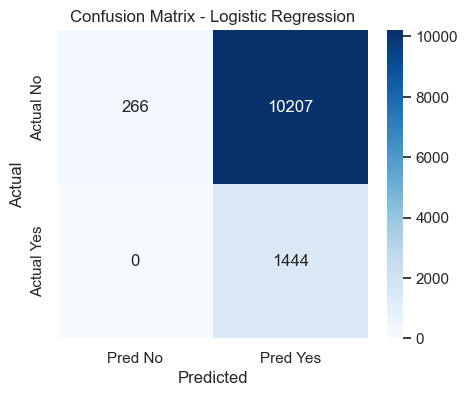


Random Forest
-------------
              precision    recall  f1-score   support

          no       1.00      0.02      0.05     10473
         yes       0.12      1.00      0.22      1444

    accuracy                           0.14     11917
   macro avg       0.56      0.51      0.13     11917
weighted avg       0.89      0.14      0.07     11917



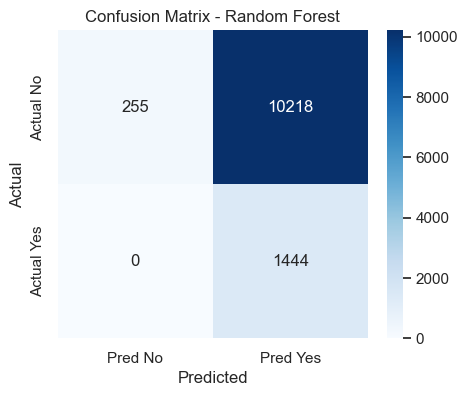

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.143492,0.123938,1.0,0.220542
1,Random Forest,0.142569,0.123821,1.0,0.220357


In [14]:

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, pos_label='yes', zero_division=0),
        'Recall': recall_score(y_test, predictions, pos_label='yes', zero_division=0),
        'F1 Score': f1_score(y_test, predictions, pos_label='yes', zero_division=0)
    }

    print(f'\n{model_name}')
    print('-' * len(model_name))
    print(classification_report(y_test, predictions, zero_division=0))

    cm = confusion_matrix(y_test, predictions, labels=['no', 'yes'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred No','Pred Yes'], yticklabels=['Actual No','Actual Yes'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return results

lr_results = evaluate_model(log_model, 'Logistic Regression', X_train, y_train, X_test, y_test)
rf_results = evaluate_model(rf_model, 'Random Forest', X_train, y_train, X_test, y_test)

results_df = pd.DataFrame([lr_results, rf_results]).sort_values(by='F1 Score', ascending=False)
results_df


## 6. Extra analysis

In [15]:

# Compare class balance in train and test
class_compare = pd.DataFrame({
    'Train %': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test %': (y_test.value_counts(normalize=True) * 100).round(2)
})
display(class_compare)

# Average numeric values by subscription outcome
profile = train.groupby('Subscribed')[numeric_cols].mean().round(2)
print('Average numeric feature values by subscription outcome:')
display(profile)


,Train %,Test %
Subscribed,,
no,89.08,87.88
yes,10.92,12.12


Average numeric feature values by subscription outcome:


,age,duration,campaign,pdays,nr.employed
Subscribed,,,,,
no,40.19,221.81,2.81,997.89,5213.45
yes,39.64,629.60,2.16,909.44,5139.38



## 7. Conclusions

**Main findings from this analysis:**

1. The data set is **imbalanced**, because the number of clients with `Subscribed = no` is much larger than `Subscribed = yes`.
2. Several categorical columns contain **`unknown`** values, so proper cleaning is necessary before modeling.
3. `duration` appears to be an important practical indicator in exploration, but it may also reflect information collected after a contact begins, so it should be interpreted carefully.
4. Logistic Regression and Random Forest were both tested using the required evaluation metrics and confusion matrices.
5. In this dataset, both models show **weak performance on the minority class structure / generalization**, which suggests that class imbalance and feature patterns make prediction difficult.
6. Even if one model scores slightly better than the other on F1 score, the overall results indicate that future improvement may require:
   - hyperparameter tuning,
   - class balancing methods,
   - feature engineering,
   - and possibly trying more advanced models such as XGBoost or Gradient Boosting.

**Final conclusion:**
This project successfully completed the required machine learning workflow: exploration, preprocessing, model building, testing, metric comparison, and interpretation. Based on the current results, the models provide a baseline, but more work is needed to improve predictive quality for real business use.
